lets do some classification

In [1]:
from sklearn.datasets import make_circles

In [2]:
samples=1000

X,y = make_circles(samples,noise=0.03,random_state=37)

In [3]:
import torch
X=  torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=37)

In [6]:
from torch import nn

In [7]:
device="cuda" if torch.cuda.is_available() else  "cpu"
device

'cuda'

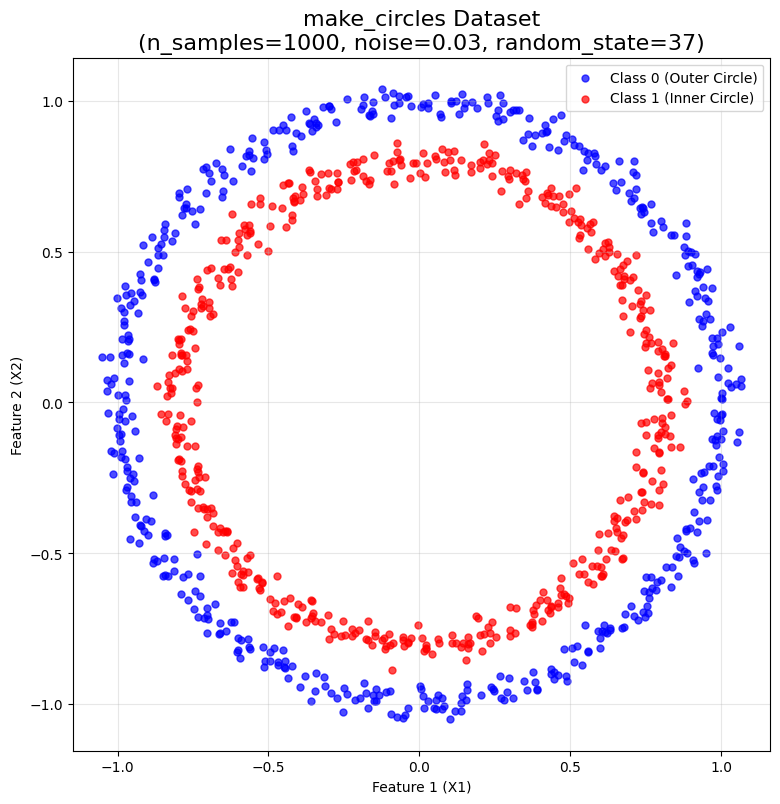

In [8]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import numpy as np

# Data generate karo
X, y = make_circles(n_samples=1000, noise=0.03, random_state=37)

# Plot
plt.figure(figsize=(9, 9))

# Class 0 (usually outer circle) - Blue
plt.scatter(X[y == 0, 0], X[y == 0, 1], 
            c='blue', label='Class 0 (Outer Circle)', 
            alpha=0.7, s=25)

# Class 1 (usually inner circle) - Red
plt.scatter(X[y == 1, 0], X[y == 1, 1], 
            c='red', label='Class 1 (Inner Circle)', 
            alpha=0.7, s=25)

plt.title('make_circles Dataset\n(n_samples=1000, noise=0.03, random_state=37)', fontsize=16)
plt.xlabel('Feature 1 (X1)')
plt.ylabel('Feature 2 (X2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')        # Circles perfect round dikhne ke liye
plt.show()

In [9]:
model0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)
    


In [10]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

In [11]:
y_logits=model0(X_test.to(device))[:5]
y_logits

tensor([[-0.3626],
        [-0.3673],
        [-0.0456],
        [-0.2083],
        [-0.0904]], device='cuda:0', grad_fn=<SliceBackward0>)

In [12]:
device

'cuda'

In [13]:
class CircleV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net= nn.Sequential(
            nn.Linear(2,10),
            nn.ReLU(),
            nn.Linear(10,10),
            nn.ReLU(),
            nn.Linear(10,1)
        )


    def forward(self,x):
        return self.net(x)

model3=CircleV2().to(device)
model3

CircleV2(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [14]:


loss_fn=nn.BCEWithLogitsLoss()


optimizer=torch.optim.Adam(model3.parameters(),lr=0.01)

In [15]:

epochs=1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):

    model3.train()

    y_logits=model3(X_train)
    y_logits=y_logits.squeeze()
    y_pred=torch.round(torch.sigmoid(y_logits))

    loss=loss_fn(y_logits,y_train)
    acc=accuracy_fn(y_true=y_train,y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()


    model3.eval()

    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model3(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
      # 2. Calculate loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.71492, Accuracy: 48.88% | Test Loss: 0.69024, Test Accuracy: 54.50%
Epoch: 100 | Loss: 0.07401, Accuracy: 99.75% | Test Loss: 0.08802, Test Accuracy: 100.00%
Epoch: 200 | Loss: 0.01025, Accuracy: 99.88% | Test Loss: 0.01765, Test Accuracy: 100.00%
Epoch: 300 | Loss: 0.00522, Accuracy: 100.00% | Test Loss: 0.01032, Test Accuracy: 100.00%
Epoch: 400 | Loss: 0.00340, Accuracy: 100.00% | Test Loss: 0.00757, Test Accuracy: 100.00%
Epoch: 500 | Loss: 0.00247, Accuracy: 100.00% | Test Loss: 0.00618, Test Accuracy: 100.00%
Epoch: 600 | Loss: 0.00191, Accuracy: 100.00% | Test Loss: 0.00498, Test Accuracy: 100.00%
Epoch: 700 | Loss: 0.00154, Accuracy: 100.00% | Test Loss: 0.00417, Test Accuracy: 100.00%
Epoch: 800 | Loss: 0.00128, Accuracy: 100.00% | Test Loss: 0.00359, Test Accuracy: 100.00%
Epoch: 900 | Loss: 0.00108, Accuracy: 100.00% | Test Loss: 0.00308, Test Accuracy: 100.00%


In [16]:
#multiclas classification